<a href="https://colab.research.google.com/github/Vermont-Complex-Systems/storywrangler/blob/wiki-hedo/notebooks/storywrangler_multi_platforms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -U storywrangler

In [ ]:
# latest py-allotax version still on a branch
!pip install git+https://github.com/compstorylab/py-allotax.git@allotax-core

  Cloning https://github.com/compstorylab/py-allotax.git (to revision allotax-core) to /tmp/pip-req-build-98ffdluc
  Running command git clone --filter=blob:none --quiet https://github.com/compstorylab/py-allotax.git /tmp/pip-req-build-98ffdluc
  Running command git checkout -b allotax-core --track origin/allotax-core
  Switched to a new branch 'allotax-core'
  Branch 'allotax-core' set up to track remote branch 'allotax-core' from 'origin'.
  Resolved https://github.com/compstorylab/py-allotax.git to commit 9d3754ddcd1516bd2ba78d0061acf307dfa40c35
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
# colab's slim Ubuntu image lacks Chrome's system libraries for writing the allotax plot
!apt-get -qq update && apt-get -qq install -y libatk1.0-0 libatk-bridge2.0-0 libcups2 libasound2 libgbm1 libnss3 libxkbcommon0 libxcomposite1 libxdamage1 libxfixes3 libxrandr2

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [ ]:
# local packages
from storywrangler import Storywrangler
from py_allotax import allotaxonograph

import matplotlib.cm as cm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

In [ ]:
import storywrangler
storywrangler.__version__

'0.0.9'

In [ ]:
client=Storywrangler()

In [ ]:
twitter = client.dataset("twitter")
reddit = client.dataset("reddit")

In [ ]:
ts1 = twitter.term_series(
    "Trump", entity="United States", lang="en", ngram_size=1, window=365*5
    ).df().set_index("date")['rank']
ts2 = twitter.term_series(
    "Biden", entity="United States", lang="en", ngram_size=1, window=365*5
    ).df().set_index("date")['rank']
ts_df=pd.merge(ts1, ts2, on="date", suffixes=["_Trump", "_Biden"])

In [ ]:
# no entities needed here
tsr1 = reddit.term_series(
    "Trump", lang="en", n=1, window=365*5
    ).df().set_index("date")['rank']
tsr2 = reddit.term_series(
    "Biden", lang="en", n=1, window=365*5
    ).df().set_index("date")['rank']
tsr_df=pd.merge(tsr1, tsr2, on="date", suffixes=["_Trump", "_Biden"])

In [ ]:
multi_df=pd.merge(ts_df, tsr_df, on="date", how="left", suffixes=["_twitter", "_reddit"])

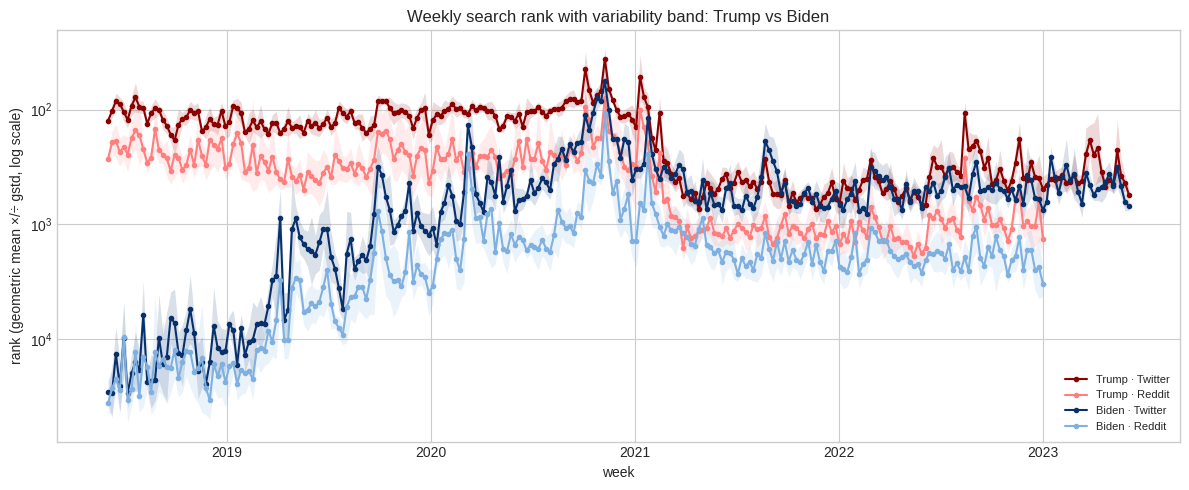

In [ ]:
multi_df.index = pd.to_datetime(multi_df.index)
df = multi_df.sort_index()

# geometric mean & geometric std, computed in log space
logdf = np.log(df)
center = np.exp(logdf.resample("W").mean())          # geometric mean
gsd    = np.exp(logdf.resample("W").std())           # geometric std (a ratio, ≥1)
upper  = center * gsd
lower  = center / gsd

styles = {
    "rank_Trump_twitter": dict(color="#8B0000", label="Trump · Twitter"),
    "rank_Trump_reddit":  dict(color="#FF7F7F", label="Trump · Reddit"),
    "rank_Biden_twitter": dict(color="#08306B", label="Biden · Twitter"),
    "rank_Biden_reddit":  dict(color="#7FB0E0", label="Biden · Reddit"),
}

fig, ax = plt.subplots(figsize=(12, 5))
for col, st in styles.items():
    ax.plot(center.index, center[col], marker="o", ms=3,
            color=st["color"], label=st["label"])
    ax.fill_between(center.index, lower[col], upper[col],
                    color=st["color"], alpha=0.15, linewidth=0)

ax.set_yscale("log")
ax.invert_yaxis()
ax.set_ylabel("rank (geometric mean ×/÷ gstd, log scale)")
ax.set_xlabel("week")
ax.set_title("Weekly search rank with variability band: Trump vs Biden")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

## Adding Wiki to the mix

In [ ]:
wiki = client.dataset("wikimedia", "ngrams")

In [ ]:
# only english for now
tsw1=wiki.term_series("Trump", entity="United States", ngram_size=1, window=365*5
    ).df().set_index("date")['rank']
tsw2=wiki.term_series("Biden", entity="United States", ngram_size=1, window=365*5
    ).df().set_index("date")['rank']

In [ ]:
tsw_df=pd.merge(tsw1, tsw2, on="date", suffixes=["_Trump", "_Biden"])
tsw_df.index = pd.to_datetime(tsw_df.index)

In [ ]:
multi_df2=pd.merge(multi_df, tsw_df, on="date", how="outer")

In [ ]:
multi_df2=multi_df2.rename(columns={"rank_Trump": "rank_Trump_wiki","rank_Biden": "rank_Biden_wiki"})

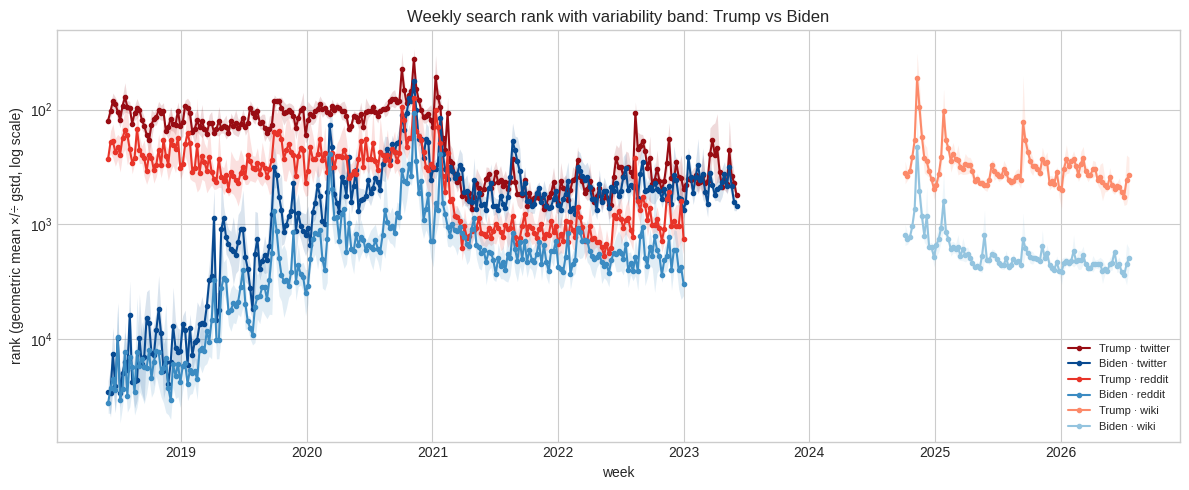

In [ ]:
df = multi_df2.sort_index()

# geometric mean & geometric std, computed in log space
logdf = np.log(df)
center = np.exp(logdf.resample("W").mean())          # geometric mean
gsd    = np.exp(logdf.resample("W").std())           # geometric std (a ratio, ≥1)
upper  = center * gsd
lower  = center / gsd

platforms = ["twitter", "reddit", "wiki"]   # dark → light
reds  = cm.Reds( np.linspace(0.9, 0.4, len(platforms)))
blues = cm.Blues(np.linspace(0.9, 0.4, len(platforms)))

styles = {}
for i, plat in enumerate(platforms):
    styles[f"rank_Trump_{plat}"] = dict(color=reds[i],  label=f"Trump · {plat}")
    styles[f"rank_Biden_{plat}"] = dict(color=blues[i], label=f"Biden · {plat}")

fig, ax = plt.subplots(figsize=(12, 5))
for col, st in styles.items():
    ax.plot(center.index, center[col], marker="o", ms=3,
            color=st["color"], label=st["label"])
    ax.fill_between(center.index, lower[col], upper[col],
                    color=st["color"], alpha=0.15, linewidth=0)

ax.set_yscale("log")
ax.invert_yaxis()
ax.set_ylabel("rank (geometric mean ×/÷ gstd, log scale)")
ax.set_xlabel("week")
ax.set_title("Weekly search rank with variability band: Trump vs Biden")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()